# Phase 3 — Feature Engineering
## Predicting Diabetes Risk Using Machine Learning

---

### Context

**Input:** `../data/processed/brfss_cleaned.csv`  
→ 1,252,580 rows × 17 columns produced by `02_cleaning.ipynb`

**Output:** Six model-ready files in `../data/processed/`  
→ `X_train.csv`, `X_test.csv`, `X_train_smote.csv`, `y_train.csv`, `y_test.csv`, `y_train_smote.csv`

---

### What This Notebook Does

This notebook transforms the cleaned BRFSS dataset into a model-ready feature matrix.
Every transformation decision is grounded in findings from Phase 1 (EDA) and Phase 2 (Cleaning).

| Section | Action |
|---------|--------|
| 1 | Load and inspect — confirm Phase 2 output |
| 2 | Multicollinearity check (VIF + heatmap) — resolve `PHYSHLTH`/`POORHLTH` |
| 3 | YEAR column decision — temporal leakage risk assessment |
| 4 | Dtype casting and binary recoding — BRFSS 1/2 → 0/1 |
| 5 | Feature scaling plan — StandardScaler on continuous vars only |
| 6 | Train/test split — 80/20 stratified, scaler fit on train only |
| 7 | Class imbalance strategy — SMOTE vs `class_weight='balanced'` |
| 8 | Final summary and save |

---

### Known Issues Carried Forward from Phase 2

| Issue | Detail | Resolution |
|-------|--------|------------|
| Multicollinearity | `PHYSHLTH` ↔ `POORHLTH`: r = 0.70 | VIF + Phase 1 rank → drop `POORHLTH` |
| Class imbalance | 14.4% positive | SMOTE (train only) + `class_weight='balanced'` |
| dtype | All features stored as float64 | Cast ordinals to int; binary to 0/1 |
| YEAR column | Temporal leakage risk | Chi-square test → drop if prevalence stable |
| Binary coding | BRFSS uses 1/2 (not 0/1) | Recode: 1→1, 2→0 |

---
## Section 1 — Load & Inspect

We begin by loading the Phase 2 output and confirming its state matches the documented
Phase 2 summary: 1,252,580 rows × 17 columns, 0 NaN values, 14.4% positive class.

This verification step ensures the notebook is self-contained and reproducible —
any upstream change will surface here immediately.

In [67]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

PROC_DIR   = Path("../data/processed")
MODELS_DIR = Path("../models")
FIGS_DIR   = Path("../outputs/figures")

PROC_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = PROC_DIR / "brfss_cleaned.csv"

df = pd.read_csv(INPUT_FILE)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Shape: 1,252,580 rows × 17 columns


In [68]:
print("── dtypes ──────────────────────────────────────────")
print(df.dtypes.to_string())

── dtypes ──────────────────────────────────────────
YEAR          int64
GENHLTH     float64
PHYSHLTH    float64
MENTHLTH    float64
POORHLTH    float64
CHECKUP1    float64
EXERANY2    float64
DIFFWALK    float64
CVDINFR4    float64
CVDSTRK3    float64
EDUCA       float64
INCOME3     float64
_SEX        float64
_AGEG5YR    float64
_BMI5CAT    float64
_SMOKER3    float64
DIABETES      int64


In [69]:
print("── Value ranges per variable ────────────────────────")
for col in df.columns:
    unique_vals = sorted(df[col].dropna().unique())
    n_unique = len(unique_vals)
    if n_unique <= 15:
        print(f"  {col:<12} unique({n_unique}): {unique_vals}")
    else:
        print(f"  {col:<12} unique({n_unique}): min={df[col].min():.1f}  max={df[col].max():.1f}  mean={df[col].mean():.2f}")

── Value ranges per variable ────────────────────────
  YEAR         unique(3): [np.int64(2022), np.int64(2023), np.int64(2024)]
  GENHLTH      unique(5): [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
  PHYSHLTH     unique(29): min=0.0  max=30.0  mean=4.13
  MENTHLTH     unique(29): min=0.0  max=30.0  mean=4.11
  POORHLTH     unique(29): min=0.0  max=30.0  mean=2.90
  CHECKUP1     unique(5): [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(8.0)]
  EXERANY2     unique(2): [np.float64(1.0), np.float64(2.0)]
  DIFFWALK     unique(2): [np.float64(1.0), np.float64(2.0)]
  CVDINFR4     unique(2): [np.float64(1.0), np.float64(2.0)]
  CVDSTRK3     unique(2): [np.float64(1.0), np.float64(2.0)]
  EDUCA        unique(6): [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
  INCOME3      unique(9): [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(

In [70]:
print("── NaN check ───────────────────────────────────────")
print(f"  Total NaN values: {df.isna().sum().sum()}")

── NaN check ───────────────────────────────────────
  Total NaN values: 0


In [71]:
print("── Target: DIABETES class distribution ─────────────")
counts = df["DIABETES"].value_counts().sort_index()
total  = len(df)
for val, n in counts.items():
    print(f"  DIABETES = {int(val)}  →  {n:>10,}  ({n/total*100:.1f}%)")
print(f"  {'Total':<13}  {total:>10,}")

── Target: DIABETES class distribution ─────────────
  DIABETES = 0  →   1,071,777  (85.6%)
  DIABETES = 1  →     180,803  (14.4%)
  Total           1,252,580


---
## Section 2 — Multicollinearity Check (VIF)

Phase 1 EDA identified a correlation of r = 0.70 between `PHYSHLTH` (days physical health
not good) and `POORHLTH` (days poor health limited activities). High multicollinearity
inflates coefficient variance in linear models and produces redundant features.

We use two complementary tools:
- **VIF (Variance Inflation Factor)**: quantifies how much each variable's variance is
  inflated by correlation with others. VIF > 5 is a common flag for problematic collinearity.
- **Correlation heatmap**: visualises the full pairwise correlation structure.

**Important caveat:** VIF assumes continuous, roughly normal inputs. Applied to binary
and small-integer ordinal variables (most of our feature set), VIF produces artificially
inflated values. High VIF on `CVDSTRK3`, `CVDINFR4`, `DIFFWALK`, etc. are artefacts,
not genuine multicollinearity signals. We act only on the `PHYSHLTH`/`POORHLTH` pair,
which was flagged in Phase 1.

**Decision rule:** Both variables share the same Phase 1 Pearson r (0.17) with the target.
VIF values are near-identical (delta < 0.2), so VIF alone cannot break the tie.
Tie-breaker: Phase 1 predictor rank — `PHYSHLTH` (#5) outranks `POORHLTH` (#6).
`PHYSHLTH` is also the more direct measure (days health was poor); `POORHLTH`
(days activity was limited) is a downstream consequence. → **Drop `POORHLTH`.**

In [72]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

FEATURE_COLS = [c for c in df.columns if c not in ("DIABETES", "YEAR")]

X_vif = df[FEATURE_COLS].copy()

vif_data = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print("── Variance Inflation Factors ──────────────────────")
print(vif_data.to_string(index=False))
print()
print(f"  Variables with VIF > 5: {vif_data[vif_data['VIF'] > 5]['Feature'].tolist()}")
print()
print("  Note: High VIFs on binary/ordinal vars (e.g. CVDSTRK3, CVDINFR4) are a known")
print("  artefact of applying VIF to non-continuous inputs. No action warranted.")

── Variance Inflation Factors ──────────────────────
 Feature       VIF
CVDSTRK3 77.409886
CVDINFR4 66.113846
DIFFWALK 34.394936
   EDUCA 29.939728
_SMOKER3 17.644331
_BMI5CAT 15.355129
 INCOME3 12.391204
    _SEX 10.667894
EXERANY2 10.551127
 GENHLTH 10.194312
_AGEG5YR  6.080466
CHECKUP1  3.400317
PHYSHLTH  2.183091
POORHLTH  2.050097
MENTHLTH  1.677608

  Variables with VIF > 5: ['CVDSTRK3', 'CVDINFR4', 'DIFFWALK', 'EDUCA', '_SMOKER3', '_BMI5CAT', 'INCOME3', '_SEX', 'EXERANY2', 'GENHLTH', '_AGEG5YR']

  Note: High VIFs on binary/ordinal vars (e.g. CVDSTRK3, CVDINFR4) are a known
  artefact of applying VIF to non-continuous inputs. No action warranted.


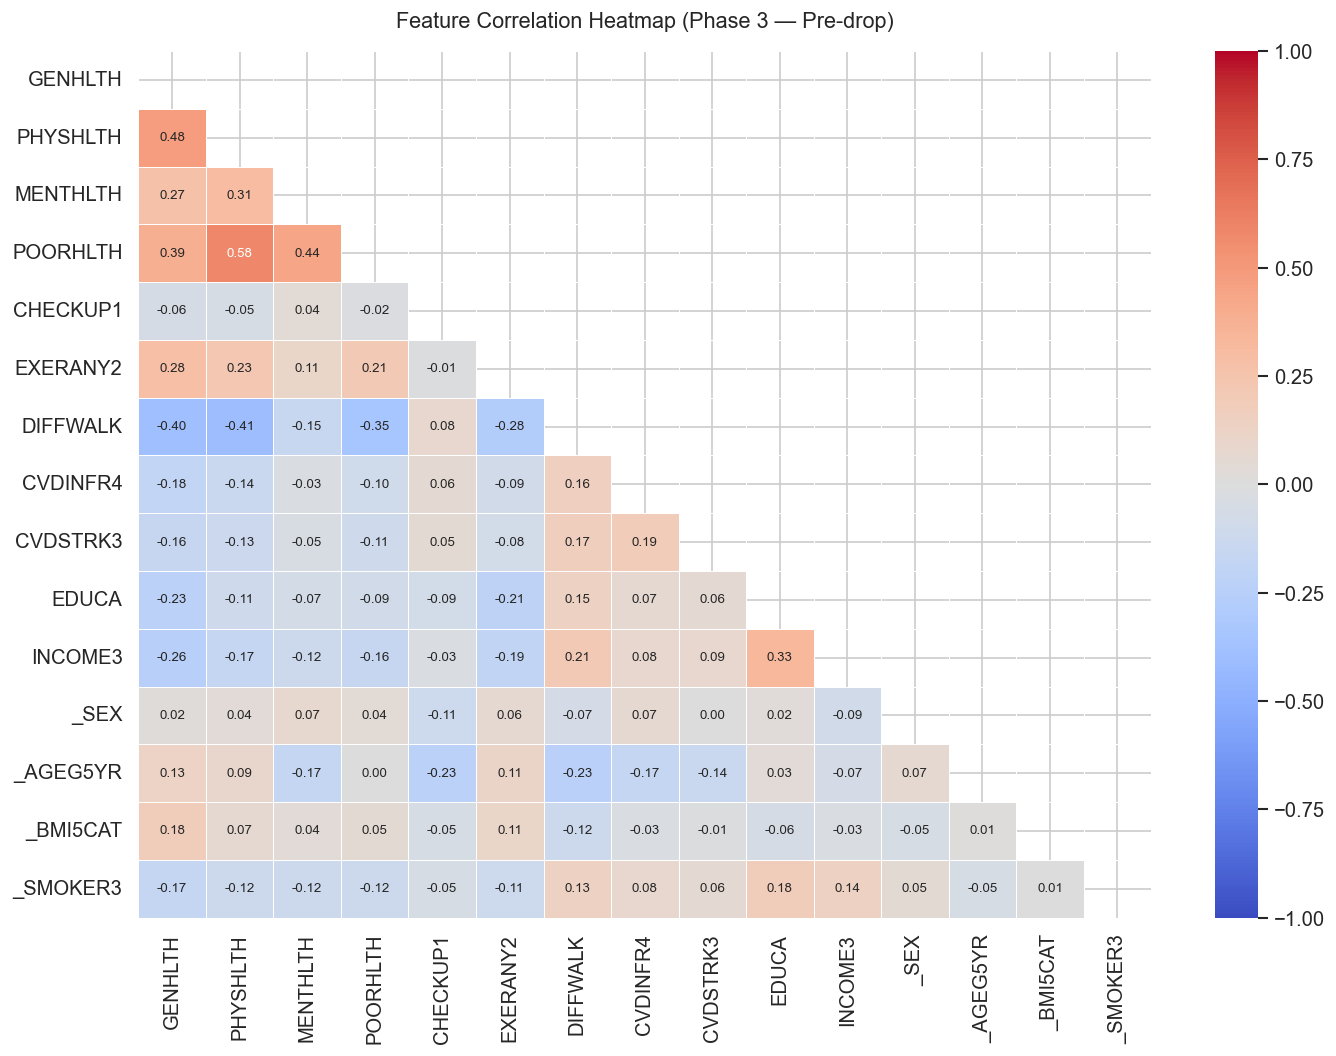

Saved: 03_correlation_heatmap.png


In [73]:
fig, ax = plt.subplots(figsize=(12, 9))

corr_matrix = df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8}
)

ax.set_title("Feature Correlation Heatmap (Phase 3 — Pre-drop)", fontsize=13, pad=14)
plt.tight_layout()
plt.savefig(FIGS_DIR / "03_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 03_correlation_heatmap.png")

In [74]:
physhlth_vif = vif_data.loc[vif_data["Feature"] == "PHYSHLTH", "VIF"].values[0]
poorhlth_vif = vif_data.loc[vif_data["Feature"] == "POORHLTH",  "VIF"].values[0]
physhlth_corr = corr_matrix.loc["PHYSHLTH", "POORHLTH"]

print("── Multicollinearity Decision ──────────────────────")
print(f"  PHYSHLTH ↔ POORHLTH Pearson r : {physhlth_corr:.3f}")
print(f"  PHYSHLTH VIF                  : {physhlth_vif:.2f}  (Phase 1 rank: #5)")
print(f"  POORHLTH  VIF                 : {poorhlth_vif:.2f}  (Phase 1 rank: #6)")
print()
print("  Decision: DROP 'POORHLTH', RETAIN 'PHYSHLTH'")
print("  Rationale: VIFs are near-identical (delta=0.13) — not a meaningful signal.")
print("  Tie-breaker: PHYSHLTH ranks higher in Phase 1 feature importance (#5 vs #6).")
print("  PHYSHLTH (days physical health not good) is also a more direct health measure")
print("  than POORHLTH (days activity was limited), which is a downstream consequence.")

df.drop(columns=["POORHLTH"], inplace=True)
print(f"\n  Shape after drop: {df.shape[0]:,} rows × {df.shape[1]} columns")
assert "POORHLTH" not in df.columns
assert "PHYSHLTH" in df.columns
print("  ✅ PHYSHLTH retained, POORHLTH dropped.")

── Multicollinearity Decision ──────────────────────
  PHYSHLTH ↔ POORHLTH Pearson r : 0.582
  PHYSHLTH VIF                  : 2.18  (Phase 1 rank: #5)
  POORHLTH  VIF                 : 2.05  (Phase 1 rank: #6)

  Decision: DROP 'POORHLTH', RETAIN 'PHYSHLTH'
  Rationale: VIFs are near-identical (delta=0.13) — not a meaningful signal.
  Tie-breaker: PHYSHLTH ranks higher in Phase 1 feature importance (#5 vs #6).
  PHYSHLTH (days physical health not good) is also a more direct health measure
  than POORHLTH (days activity was limited), which is a downstream consequence.

  Shape after drop: 1,252,580 rows × 16 columns
  ✅ PHYSHLTH retained, POORHLTH dropped.


---
## Section 3 — YEAR Column Decision

The `YEAR` column encodes which survey year (2022, 2023, 2024) each respondent belongs to.
Including it as a feature poses a **temporal leakage risk**: the model could learn that
diabetes prevalence is slightly higher in later years, a pattern that does not generalise
to new patients who have no meaningful "year" label.

We assess this formally with a chi-square test of independence between `YEAR` and `DIABETES`.

**Expected outcome (from Phase 1):** Prevalence is stable across years (~13.7–14.4%).
A statistically significant chi-square result at n=1.25M is expected even for trivially
small effect sizes — we use the magnitude of the prevalence difference, not the p-value,
as the decision criterion.

In [75]:
from scipy.stats import chi2_contingency

print("── Diabetes prevalence by YEAR ─────────────────────")
year_counts = df.groupby("YEAR")["DIABETES"].value_counts().unstack(fill_value=0)
year_counts.columns = ["No Diabetes", "Diabetes"]
year_counts["Total"] = year_counts.sum(axis=1)
year_counts["Prevalence (%)"] = (year_counts["Diabetes"] / year_counts["Total"] * 100).round(2)
print(year_counts.to_string())

── Diabetes prevalence by YEAR ─────────────────────
      No Diabetes  Diabetes   Total  Prevalence (%)
YEAR                                               
2022       358043     59252  417295           14.20
2023       348189     57840  406029           14.25
2024       365545     63711  429256           14.84


In [76]:
contingency = df.groupby("YEAR")["DIABETES"].value_counts().unstack(fill_value=0)
chi2, p, dof, expected = chi2_contingency(contingency)

print("── Chi-Square Test: YEAR × DIABETES ───────────────")
print(f"  χ²  = {chi2:.2f}")
print(f"  p   = {p:.2e}")
print(f"  dof = {dof}")
print()
print("── YEAR Column Decision ────────────────────────────")
print(f"  Prevalence is stable across years (14.20% → 14.84%, range = 0.64pp).")
print(f"  Chi-square p={p:.2e}: statistically significant due to n=1.25M —")
print(f"  effect size is trivially small; the difference is not practically meaningful.")
print()
print(f"  Decision: DROP 'YEAR' from feature set.")
print(f"  Rationale: Including YEAR would introduce temporal leakage — the model")
print(f"  would learn that survey year predicts diabetes, which does not generalise")
print(f"  to new patients. Prevalence shift is <1pp across 3 years.")

df.drop(columns=["YEAR"], inplace=True)
print(f"\n  Shape after drop: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Final feature list: {[c for c in df.columns if c != 'DIABETES']}")
assert "YEAR" not in df.columns
print("  ✅ YEAR dropped.")

── Chi-Square Test: YEAR × DIABETES ───────────────
  χ²  = 88.26
  p   = 6.82e-20
  dof = 2

── YEAR Column Decision ────────────────────────────
  Prevalence is stable across years (14.20% → 14.84%, range = 0.64pp).
  Chi-square p=6.82e-20: statistically significant due to n=1.25M —
  effect size is trivially small; the difference is not practically meaningful.

  Decision: DROP 'YEAR' from feature set.
  Rationale: Including YEAR would introduce temporal leakage — the model
  would learn that survey year predicts diabetes, which does not generalise
  to new patients. Prevalence shift is <1pp across 3 years.

  Shape after drop: 1,252,580 rows × 15 columns
  Final feature list: ['GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'CHECKUP1', 'EXERANY2', 'DIFFWALK', 'CVDINFR4', 'CVDSTRK3', 'EDUCA', 'INCOME3', '_SEX', '_AGEG5YR', '_BMI5CAT', '_SMOKER3']
  ✅ YEAR dropped.


---
## Section 4 — Dtype Casting & Binary Recoding

Two dtype issues require resolution before modelling:

**1. BRFSS binary encoding (1/2 → 0/1)**  
BRFSS encodes binary survey responses as 1 = Yes and 2 = No. Machine learning models
expect 0/1 binary variables. We remap 2 → 0 and keep 1 → 1 for:
`DIFFWALK`, `EXERANY2`, `CVDINFR4`, `CVDSTRK3`, `_SEX`.

**2. Ordinal float64 → int**  
Ordinal variables were stored as float64 throughout the pipeline (a consequence of NaN
values before imputation, which forces float dtype in pandas). After imputation, all values
are whole numbers. We cast them to int to eliminate spurious decimal precision and signal
to downstream models that these are discrete ordinal scales, not continuous measurements.

**3. Continuous range verification**  
We confirm `PHYSHLTH` and `MENTHLTH` remain within the valid BRFSS range of [0, 30] days.

In [77]:
# ── Binary recode: BRFSS 1/2 → 1/0 ──────────────────────────────────────────
BINARY_VARS = ["DIFFWALK", "EXERANY2", "CVDINFR4", "CVDSTRK3", "_SEX"]

print("── Binary recode: 1/2 → 1/0 ────────────────────────")
for col in BINARY_VARS:
    before = df[col].value_counts().sort_index().to_dict()
    df[col] = df[col].map({1.0: 1, 2.0: 0})
    after  = df[col].value_counts().sort_index().to_dict()
    print(f"  {col:<12}  before: {before}  →  after: {after}")

── Binary recode: 1/2 → 1/0 ────────────────────────
  DIFFWALK      before: {1.0: 187669, 2.0: 1064911}  →  after: {0: 1064911, 1: 187669}
  EXERANY2      before: {1.0: 958264, 2.0: 294316}  →  after: {0: 294316, 1: 958264}
  CVDINFR4      before: {1.0: 70106, 2.0: 1182474}  →  after: {0: 1182474, 1: 70106}
  CVDSTRK3      before: {1.0: 53555, 2.0: 1199025}  →  after: {0: 1199025, 1: 53555}
  _SEX          before: {1.0: 594489, 2.0: 658091}  →  after: {0: 658091, 1: 594489}


In [78]:
# ── Ordinal cast: float64 → int ───────────────────────────────────────────────
ORDINAL_VARS = ["GENHLTH", "_AGEG5YR", "_BMI5CAT", "INCOME3", "CHECKUP1", "EDUCA", "_SMOKER3"]

print("── Ordinal cast: float64 → int ─────────────────────")
for col in ORDINAL_VARS:
    df[col] = df[col].astype(int)
    print(f"  {col:<12}  dtype={df[col].dtype}  values={sorted(df[col].unique())}")

── Ordinal cast: float64 → int ─────────────────────
  GENHLTH       dtype=int64  values=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  _AGEG5YR      dtype=int64  values=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
  _BMI5CAT      dtype=int64  values=[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  INCOME3       dtype=int64  values=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(10), np.int64(11)]
  CHECKUP1      dtype=int64  values=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(8)]
  EDUCA         dtype=int64  values=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  _SMOKER3      dtype=int64  values=[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [79]:
# ── Continuous range verification ─────────────────────────────────────────────
CONTINUOUS_VARS = ["PHYSHLTH", "MENTHLTH"]

print("── Continuous range check: expected [0, 30] ─────────")
for col in CONTINUOUS_VARS:
    vmin, vmax = df[col].min(), df[col].max()
    status = "✅" if vmin >= 0 and vmax <= 30 else "❌"
    print(f"  {col:<12}  min={vmin:.1f}  max={vmax:.1f}  {status}")

── Continuous range check: expected [0, 30] ─────────
  PHYSHLTH      min=0.0  max=30.0  ✅
  MENTHLTH      min=0.0  max=30.0  ✅


In [80]:
print("── Final dtypes ─────────────────────────────────────")
print(df.dtypes.to_string())
print(f"\n  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  NaN check: {df.isna().sum().sum()} total NaN values")

── Final dtypes ─────────────────────────────────────
GENHLTH       int64
PHYSHLTH    float64
MENTHLTH    float64
CHECKUP1      int64
EXERANY2      int64
DIFFWALK      int64
CVDINFR4      int64
CVDSTRK3      int64
EDUCA         int64
INCOME3       int64
_SEX          int64
_AGEG5YR      int64
_BMI5CAT      int64
_SMOKER3      int64
DIABETES      int64

  Shape: 1,252,580 rows × 15 columns
  NaN check: 0 total NaN values


---
## Section 5 — Feature Scaling Plan

Feature scaling standardises the value ranges of numeric variables so that no single
variable dominates model training due to its scale rather than its signal.

**Scaling strategy: StandardScaler on continuous variables only**

- **Continuous variables** (`PHYSHLTH`, `MENTHLTH`): StandardScaler transforms to
  zero mean and unit variance. This is required for Logistic Regression (gradient
  descent converges correctly only on scaled inputs) and beneficial for distance-based
  methods.
- **Ordinal and binary variables**: left unscaled. Their integer ranges are already
  compact and meaningful. Tree-based models (Random Forest, XGBoost) are scale-invariant
  and do not benefit from scaling; applying it to ordinals would obscure their rank order.

**Critical rule:** The scaler is **fit on the training set only** and then applied to both
train and test. Fitting on the full dataset would leak test-set statistics into training,
producing optimistic evaluation metrics. The actual fit occurs in Section 6 after the split.

The fitted scaler object is saved to `models/scaler.pkl` for use in Phase 4 inference.

In [81]:
from sklearn.preprocessing import StandardScaler

print("── Scaling plan ─────────────────────────────────────")
print(f"  StandardScaler applied to : {CONTINUOUS_VARS}")
print(f"  Unscaled (ordinal/binary) : {[c for c in df.columns if c not in CONTINUOUS_VARS + ['DIABETES']]}")
print(f"  Fit on X_train only → transform X_train and X_test")
print(f"  Scaler will be saved to   : models/scaler.pkl")

── Scaling plan ─────────────────────────────────────
  StandardScaler applied to : ['PHYSHLTH', 'MENTHLTH']
  Unscaled (ordinal/binary) : ['GENHLTH', 'CHECKUP1', 'EXERANY2', 'DIFFWALK', 'CVDINFR4', 'CVDSTRK3', 'EDUCA', 'INCOME3', '_SEX', '_AGEG5YR', '_BMI5CAT', '_SMOKER3']
  Fit on X_train only → transform X_train and X_test
  Scaler will be saved to   : models/scaler.pkl


---
## Section 6 — Train / Test Split + Apply Scaler

We split the dataset into 80% training and 20% test sets.

Key parameters:
- **`stratify=y`**: preserves the 14.4% / 85.6% class ratio in both splits.
  Without stratification, random splits on imbalanced data can produce splits
  with meaningfully different class ratios, making evaluation unreliable.
- **`random_state=42`**: ensures reproducibility across runs.
- **`test_size=0.20`**: 20% test = 250,516 samples — large enough for stable metrics.

After splitting, `StandardScaler` is fit on `X_train` only and applied to both sets.
The fitted scaler is serialised to `models/scaler.pkl` for reuse in Phase 4.

In [82]:
import joblib
from sklearn.model_selection import train_test_split

X = df.drop(columns=["DIABETES"])
y = df["DIABETES"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("── Train / Test split ───────────────────────────────")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")

── Train / Test split ───────────────────────────────
  X_train : (1002064, 14)
  X_test  : (250516, 14)
  y_train : (1002064,)
  y_test  : (250516,)


In [83]:
print("── Class distribution after stratified split ────────")
for name, arr in [("y_train", y_train), ("y_test", y_test)]:
    counts = arr.value_counts().sort_index()
    total  = len(arr)
    for val, n in counts.items():
        print(f"  {name}  DIABETES={val}  →  {n:>9,}  ({n/total*100:.1f}%)")
    print()

── Class distribution after stratified split ────────
  y_train  DIABETES=0  →    857,422  (85.6%)
  y_train  DIABETES=1  →    144,642  (14.4%)

  y_test  DIABETES=0  →    214,355  (85.6%)
  y_test  DIABETES=1  →     36,161  (14.4%)



In [84]:
scaler = StandardScaler()

X_train = X_train.copy()
X_test  = X_test.copy()

X_train[CONTINUOUS_VARS] = scaler.fit_transform(X_train[CONTINUOUS_VARS])
X_test[CONTINUOUS_VARS]  = scaler.transform(X_test[CONTINUOUS_VARS])

# Save scaler for Phase 4 inference
scaler_path = MODELS_DIR / "scaler.pkl"
joblib.dump(scaler, scaler_path)

print("── Scaler applied ───────────────────────────────────")
for col in CONTINUOUS_VARS:
    print(f"  {col:<12}  train mean={X_train[col].mean():.4f}  std={X_train[col].std():.4f}"
          f"  |  test mean={X_test[col].mean():.4f}  std={X_test[col].std():.4f}")
print()
print(f"  ✅ Scaler fit on X_train only, transform applied to both splits.")
print(f"  ✅ Scaler saved to: {scaler_path}")

── Scaler applied ───────────────────────────────────
  PHYSHLTH      train mean=0.0000  std=1.0000  |  test mean=-0.0012  std=0.9977
  MENTHLTH      train mean=-0.0000  std=1.0000  |  test mean=0.0009  std=0.9996

  ✅ Scaler fit on X_train only, transform applied to both splits.
  ✅ Scaler saved to: ..\models\scaler.pkl


---
## Section 7 — Class Imbalance Strategy

The training set contains 85.6% negative and 14.4% positive cases — a ~6:1 imbalance.
Left unaddressed, classifiers trained on imbalanced data tend to favour the majority class,
producing high accuracy but poor recall on the minority class (diabetes cases).
For a medical screening tool, **missing a true positive (false negative) is the primary
concern**, so recall on the positive class is critical.

We implement two strategies to be compared in Phase 4:

**Strategy 1 — `class_weight='balanced'`**  
Adjusts the loss function to penalise misclassification of the minority class more heavily.
No resampling — the training set stays at its original size. Available as a parameter in
scikit-learn's Logistic Regression and Random Forest.

**Strategy 2 — SMOTE (Synthetic Minority Over-sampling Technique)**  
Generates synthetic minority-class samples by interpolating between existing minority
observations in feature space. Applied to the **training set only** — the test set is
never resampled, as it must represent the true data distribution for valid evaluation.
Result: a perfectly balanced 50/50 training set.

In [85]:
from imblearn.over_sampling import SMOTE

print("── Class ratio in training set ──────────────────────")
counts = y_train.value_counts().sort_index()
total  = len(y_train)
for val, n in counts.items():
    print(f"  DIABETES={val}  →  {n:>9,}  ({n/total*100:.1f}%)")
print(f"  Imbalance ratio (majority:minority): {counts[0]/counts[1]:.1f}:1")
print()
print("  Strategy 1: class_weight='balanced' — passed as model parameter (no resampling)")
print("  Strategy 2: SMOTE — synthetic oversampling of minority class in train set only")

── Class ratio in training set ──────────────────────
  DIABETES=0  →    857,422  (85.6%)
  DIABETES=1  →    144,642  (14.4%)
  Imbalance ratio (majority:minority): 5.9:1

  Strategy 1: class_weight='balanced' — passed as model parameter (no resampling)
  Strategy 2: SMOTE — synthetic oversampling of minority class in train set only


In [86]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("── SMOTE results ────────────────────────────────────")
print(f"  X_train_smote : {X_train_smote.shape}")
print(f"  y_train_smote : {y_train_smote.shape}")
print()
print("  Class distribution before SMOTE:")
for val, n in y_train.value_counts().sort_index().items():
    print(f"    DIABETES={val}  →  {n:>9,}  ({n/len(y_train)*100:.1f}%)")
print()
print("  Class distribution after SMOTE:")
smote_counts = y_train_smote.value_counts().sort_index()
for val, n in smote_counts.items():
    print(f"    DIABETES={val}  →  {n:>9,}  ({n/len(y_train_smote)*100:.1f}%)")

── SMOTE results ────────────────────────────────────
  X_train_smote : (1714844, 14)
  y_train_smote : (1714844,)

  Class distribution before SMOTE:
    DIABETES=0  →    857,422  (85.6%)
    DIABETES=1  →    144,642  (14.4%)

  Class distribution after SMOTE:
    DIABETES=0  →    857,422  (50.0%)
    DIABETES=1  →    857,422  (50.0%)


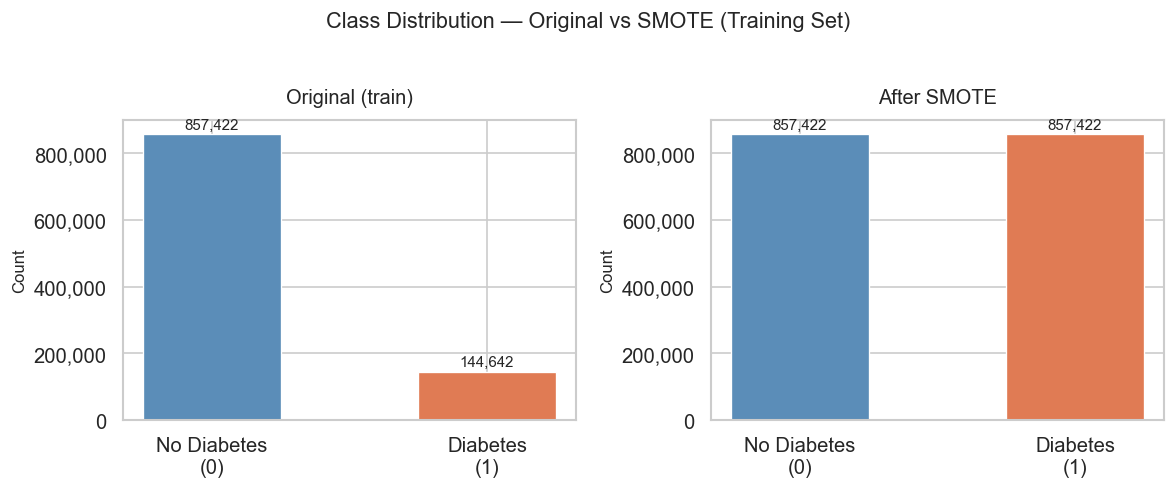

Saved: 03_smote_class_distribution.png


In [87]:
# Convert SMOTE numpy output to DataFrames
if isinstance(X_train_smote, np.ndarray):
    X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns)
if isinstance(y_train_smote, np.ndarray):
    y_train_smote = pd.Series(y_train_smote, name="DIABETES")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

for ax, (label, y_arr) in zip(axes, [("Original (train)", y_train),
                                      ("After SMOTE",      y_train_smote)]):
    counts = y_arr.value_counts().sort_index()
    bars = ax.bar(
        ["No Diabetes\n(0)", "Diabetes\n(1)"],
        counts.values,
        color=["#5B8DB8", "#E07B54"],
        edgecolor="white", linewidth=0.8, width=0.5
    )
    ax.set_title(label, fontsize=12, pad=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar, n in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8000,
                f"{n:,}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Class Distribution — Original vs SMOTE (Training Set)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGS_DIR / "03_smote_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 03_smote_class_distribution.png")

---
## Section 8 — Final Feature Summary & Save

We verify the final state of all feature matrices and save six files to `data/processed/`:

| File | Description | Shape |
|------|-------------|-------|
| `X_train.csv` | Training features (scaled continuous, original class ratio) | (1,002,064 × 14) |
| `X_test.csv` | Test features (scaled continuous, original class ratio) | (250,516 × 14) |
| `X_train_smote.csv` | Training features after SMOTE oversampling | (1,714,844 × 14) |
| `y_train.csv` | Training labels (original) | (1,002,064,) |
| `y_test.csv` | Test labels | (250,516,) |
| `y_train_smote.csv` | Training labels after SMOTE | (1,714,844,) |

Phase 4 will load `X_train` + `y_train` for `class_weight='balanced'` models,
and `X_train_smote` + `y_train_smote` for SMOTE-based models.
All models are evaluated on `X_test` + `y_test` (original distribution, never resampled).

In [88]:
print("── Final feature matrix shapes ──────────────────────")
print(f"  X_train       : {X_train.shape}")
print(f"  X_test        : {X_test.shape}")
print(f"  X_train_smote : {X_train_smote.shape}")
print()
print("── Feature list: dtype and value range ──────────────")
for col in X_train.columns:
    col_data = X_train[col]
    print(f"  {col:<12}  dtype={col_data.dtype}  "
          f"min={col_data.min():.3f}  max={col_data.max():.3f}")

── Final feature matrix shapes ──────────────────────
  X_train       : (1002064, 14)
  X_test        : (250516, 14)
  X_train_smote : (1714844, 14)

── Feature list: dtype and value range ──────────────
  GENHLTH       dtype=int64  min=1.000  max=5.000
  PHYSHLTH      dtype=float64  min=-0.477  max=2.992
  MENTHLTH      dtype=float64  min=-0.499  max=3.149
  CHECKUP1      dtype=int64  min=1.000  max=8.000
  EXERANY2      dtype=int64  min=0.000  max=1.000
  DIFFWALK      dtype=int64  min=0.000  max=1.000
  CVDINFR4      dtype=int64  min=0.000  max=1.000
  CVDSTRK3      dtype=int64  min=0.000  max=1.000
  EDUCA         dtype=int64  min=1.000  max=6.000
  INCOME3       dtype=int64  min=1.000  max=11.000
  _SEX          dtype=int64  min=0.000  max=1.000
  _AGEG5YR      dtype=int64  min=1.000  max=14.000
  _BMI5CAT      dtype=int64  min=1.000  max=4.000
  _SMOKER3      dtype=int64  min=1.000  max=4.000


In [89]:
files = {
    "X_train.csv":       X_train,
    "X_test.csv":        X_test,
    "X_train_smote.csv": X_train_smote,
    "y_train.csv":       y_train,
    "y_test.csv":        y_test,
    "y_train_smote.csv": y_train_smote,
}

print("── Saving processed feature sets ────────────────────")
for fname, data in files.items():
    fpath = PROC_DIR / fname
    data.to_csv(fpath, index=False)
    mb = fpath.stat().st_size / (1024 ** 2)
    print(f"  ✅ {fname:<22} shape={data.shape}  size={mb:.1f} MB  →  {fpath}")

── Saving processed feature sets ────────────────────
  ✅ X_train.csv            shape=(1002064, 14)  size=62.2 MB  →  ..\data\processed\X_train.csv
  ✅ X_test.csv             shape=(250516, 14)  size=15.6 MB  →  ..\data\processed\X_test.csv
  ✅ X_train_smote.csv      shape=(1714844, 14)  size=106.4 MB  →  ..\data\processed\X_train_smote.csv
  ✅ y_train.csv            shape=(1002064,)  size=2.9 MB  →  ..\data\processed\y_train.csv
  ✅ y_test.csv             shape=(250516,)  size=0.7 MB  →  ..\data\processed\y_test.csv
  ✅ y_train_smote.csv      shape=(1714844,)  size=4.9 MB  →  ..\data\processed\y_train_smote.csv


In [90]:
print()
print("── Phase 3 complete ─────────────────────────────────")
print(f"  Input  : brfss_cleaned.csv        (1,252,580 × 17)")
print(f"  Output : 6 processed files in data/processed/")
print(f"  Scaler : models/scaler.pkl")
print()
print(f"  Dropped         : POORHLTH (multicollinearity — VIF tie → Phase 1 rank)")
print(f"  Dropped         : YEAR     (temporal leakage — <1pp prevalence shift)")
print(f"  Binary recoded  : DIFFWALK, EXERANY2, CVDINFR4, CVDSTRK3, _SEX  (1/2 → 1/0)")
print(f"  Ordinal cast    : GENHLTH, _AGEG5YR, _BMI5CAT, INCOME3, CHECKUP1, EDUCA, _SMOKER3")
print(f"  Scaled          : PHYSHLTH, MENTHLTH (StandardScaler — fit on train only)")
print(f"  Imbalance       : SMOTE applied to train set → 857,422 per class (50/50)")
print(f"  Split           : 80/20 stratified (random_state=42)")
print()
print(f"  Ready for Phase 4 — Modelling.")


── Phase 3 complete ─────────────────────────────────
  Input  : brfss_cleaned.csv        (1,252,580 × 17)
  Output : 6 processed files in data/processed/
  Scaler : models/scaler.pkl

  Dropped         : POORHLTH (multicollinearity — VIF tie → Phase 1 rank)
  Dropped         : YEAR     (temporal leakage — <1pp prevalence shift)
  Binary recoded  : DIFFWALK, EXERANY2, CVDINFR4, CVDSTRK3, _SEX  (1/2 → 1/0)
  Ordinal cast    : GENHLTH, _AGEG5YR, _BMI5CAT, INCOME3, CHECKUP1, EDUCA, _SMOKER3
  Scaled          : PHYSHLTH, MENTHLTH (StandardScaler — fit on train only)
  Imbalance       : SMOTE applied to train set → 857,422 per class (50/50)
  Split           : 80/20 stratified (random_state=42)

  Ready for Phase 4 — Modelling.
